# Reading AQUAMS CO2 sensor data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from scipy.signal import medfilt

## Importing CO2 data

In [3]:
! ls ~/Laacher_See_CO2  

CR350_GMP251b.dat


In [4]:
file = '~/Laacher_See_CO2/CR350_GMP251b.dat'

In [5]:
df = pd.read_csv(file, skiprows=4, index_col=0, names=['Time', 'fid', 'voltage', 'temperature','CO2(ppm)'], delimiter=',')
df.index = pd.to_datetime(df.index, format='%Y-%m-%d %H:%M:%S')

## Conversion to dissolved CO2

In [6]:
a0 = 76.811667
a1 = -3.348169
a2 = 0.1198361
a3 = -3.1048148e-3
a4 = 3.5666666668e-5
K = a0 + a1*df['temperature'] + a2*df['temperature']**2 + a3*df['temperature']**3 + a4*df['temperature']**4

## Plotting

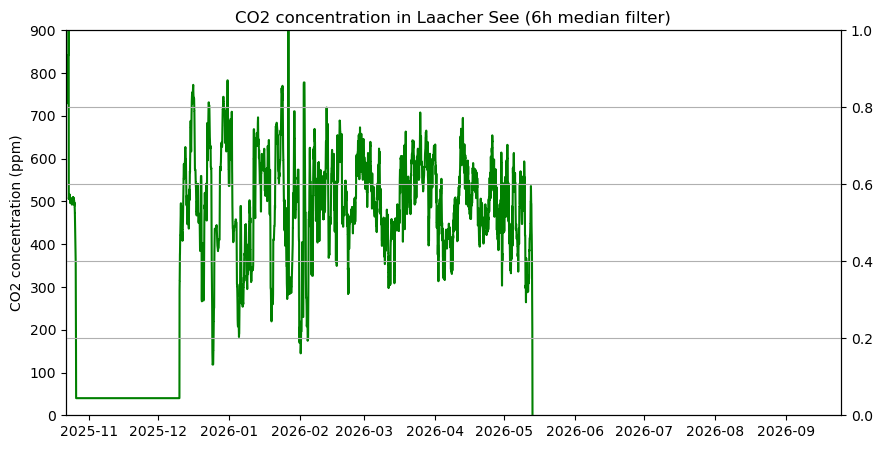

In [7]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10,5))
df_ = df.resample('5min').mean()
#start = df_.index.searchsorted(dt.datetime(2025, 10, 22))
ax.plot(df_.index, medfilt(df_['CO2(ppm)'], kernel_size=361), color='green')
axb = ax.twinx()
#axb.plot(df_.index, df_['temperature'], color='orange')
#df_['voltage'].iloc[start:].plot(ax=axb, color='k')
plt.xlim(left=dt.datetime(2025, 10, 22))
ax.set_ylim(0,900)
ax.set_ylabel('CO2 concentration (ppm)')
#axb.set_ylabel('Temperature (°C)')
plt.title('CO2 concentration in Laacher See (6h median filter)')
plt.grid()
plt.savefig('../plots/co2_laacher_see.png', dpi=300, bbox_inches='tight')
plt.show()
